In [1]:
using CSV
using Revise
using DataFrames
using StatsBase
using LinearAlgebra
using Distributions

using Stheno
using Measurements
using LogExpFunctions
import ComponentArrays: ComponentArray
using CairoMakie
using ColorSchemes
includet("src/rgp.jl")

# sin(x)

In [81]:
## Dummy test
step_test = 0.03
step_basis = 0.7
std = 0.01
l = 1
batch_size = 9
mu_prior = 0
limit_test = [-8, 8]
limit_basis = [-10, 10]

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = sin.(X_test) + rand(Normal(0, std), size(X_test)[1])

## Basis
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

θ = ComponentArray(;
    l = l,
    mu = mu_prior,
    std = std,
)

p, posterior = rgp(X_basis, X_test, Y_test, θ, batch_size)

((kernel = Squared Exponential Kernel (metric = Distances.Euclidean(0.0))
	- Scale Transform (s = 1.0), inv_cov_basis = Any[7.853634481296553 -15.868578795198356 … -0.027169533580660522 0.008237786629150264; -15.868578795198419 39.916716321683644 … 0.08960942899936739 -0.027169533580663735; … ; -0.027169533580652258 0.08960942899934858 … 39.91671632169553 -15.868578795201858; 0.008237786629147753 -0.02716953358065798 … -15.86857879520186 7.853634481297505]), Dict{Symbol, Dict{Symbol, Array{Float64}}}(:test => Dict(:mu => [-0.908410463828906, -0.771749308025636, 0.8703735798016894], :cov => [3.822162018959084e-5 -1.671563316916414e-6 -3.056680953258558e-7; -1.6715633346385167e-6 7.787163222155594e-6 4.8626057896556254e-8; -3.05668094342282e-7 4.862605907961607e-8 3.010377936733302e-5]), :basis => Dict(:mu => [0.24230436156327995, -0.06871284847097452, -0.7354576458268531, -0.9978365228494669, -0.7973256698422254, -0.2176765173322536, 0.4637747870525648, 0.9260862699534373, 0.95045767020

## Plot

In [82]:
limit_predict = [-10, 10]
step_predict = 0.32
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = sin.(X_predict)
mu, C = predict(p, posterior, X_predict)
σ = sqrt.(diag(C))

63-element Vector{Float64}:
 0.87090803880698
 0.7292739352037995
 0.5455824945846436
 0.34813499967752226
 0.17513990253231332
 0.0616113658437669
 0.012348395554924693
 0.0051619095762899655
 0.006276944331868556
 0.0032495988910967114
 ⋮
 0.006286171759883969
 0.004374598415180048
 0.009282940891182825
 0.030510237193496773
 0.10499822179101725
 0.2418989607058268
 0.4401460452699149
 0.6589922795739388
 0.8371061083054147

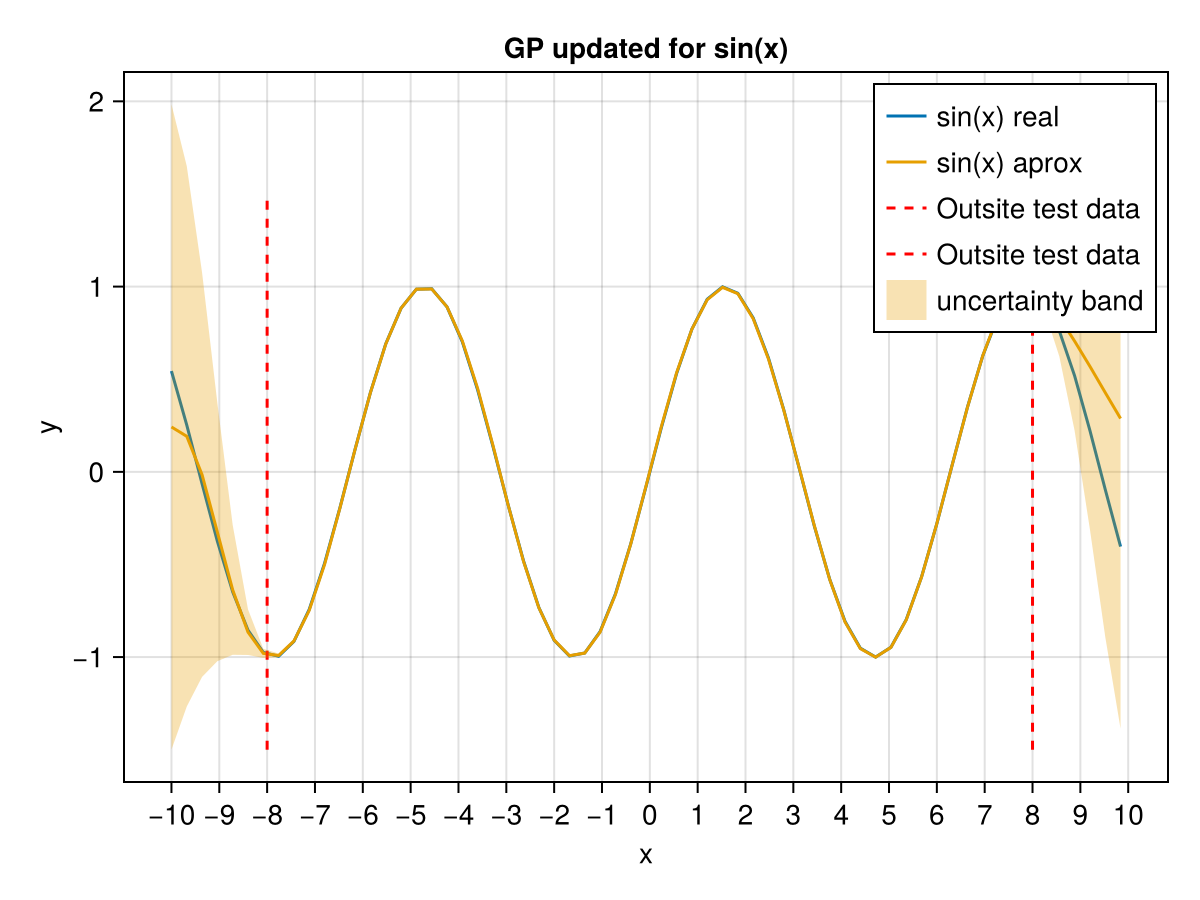

CairoMakie.Screen{IMAGE}


In [83]:
fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for sin(x)", xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "sin(x) real")
lines!(ax, X_predict, mu, label = "sin(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
axislegend(ax)
display(fig)

# $ x/2 + 25 \cdot x/(1 + x^2) \cdot cos(x) $

In [87]:
## Dummy test
step_test = 0.01
step_basis = 0.8
std = 0.01
l = 1
batch_size = 9
mu_prior = 0
limit_test = [-8, 8]
limit_basis = [-10, 10]

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = X_test/2 + 25*X_test./(1 .+ X_test.^2) .* cos.(X_test) + rand(Normal(0, std), size(X_test)[1])


## Basis
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

θ = ComponentArray(;
    l = l,
    mu = mu_prior,
    std = std,
)

p, posterior = rgp(X_basis, X_test, Y_test, θ, batch_size)


((kernel = Squared Exponential Kernel (metric = Distances.Euclidean(0.0))
	- Scale Transform (s = 1.0), inv_cov_basis = Any[4.061127330715571 -6.238493983936311 … 0.003968920262419481 -0.0013623564466084346; -6.238493983936314 13.644379014856995 … -0.011562559370889989 0.003968920262419486; … ; 0.003968920262419157 -0.011562559370889035 … 13.64437901485702 -6.238493983936324; -0.001362356446608326 0.003968920262419165 … -6.238493983936326 4.061127330715577]), Dict{Symbol, Dict{Symbol, Array{Float64}}}(:test => Dict(:mu => [-5.010768388046885, 6.94534775311635, -3.594633262226594, 0.04722271002616918, -4.141433751963535, 3.701058669867307, -2.665313552350316, 5.225963041757558], :cov => [0.00027017060180726805 -7.04719997166766e-5 … -8.185442326682878e-5 -5.265445145100709e-5; -7.047199971530306e-5 8.439036926269758e-5 … 1.088218796619668e-5 6.586132392796035e-6; … ; -8.185442326997847e-5 1.0882187966290622e-5 … 0.00011468948565217753 0.00011874506124368829; -5.2654451448971435e-5 6.586

In [88]:
limit_predict = [-10, 10]
step_predict = 0.02
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = X_predict/2 + 25*X_predict./(1 .+ X_predict.^2) .* cos.(X_predict)
mu, C = predict(p, posterior, X_predict)
σ = sqrt.(diag(C))


1001-element Vector{Float64}:
 0.8562455854738336
 0.8474448889883038
 0.838306072899224
 0.8288341599977797
 0.8190351236576862
 0.8089158761735408
 0.7984842532440148
 0.7877489946294249
 0.7767197210276431
 0.7654069072251718
 ⋮
 0.7742871345175162
 0.785389367251372
 0.796197895732453
 0.8067030097286777
 0.8168958810939199
 0.8267685868973682
 0.8363141287765464
 0.8455264484702727
 0.8544004395022619

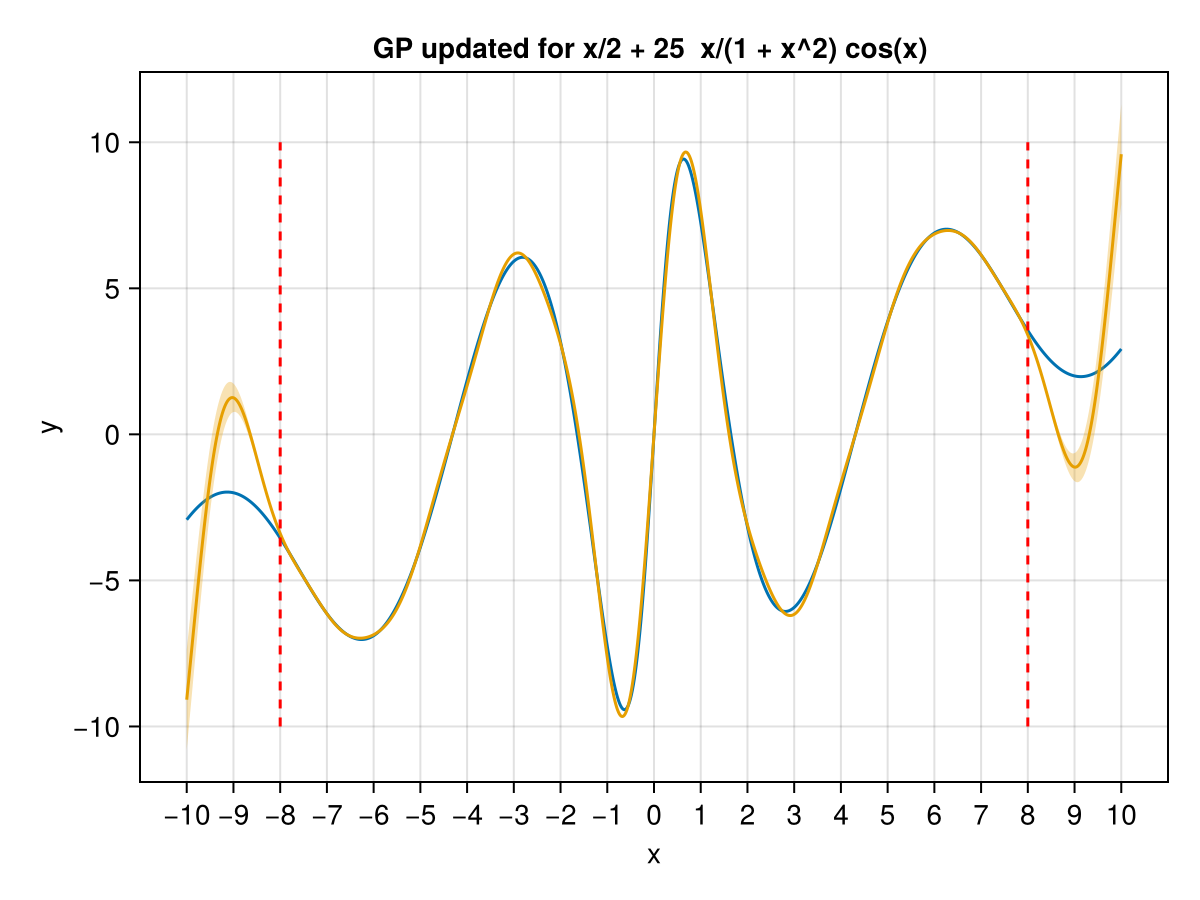

CairoMakie.Screen{IMAGE}


In [89]:
fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for x/2 + 25  x/(1 + x^2) cos(x) ", xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "f(x) real")
lines!(ax, X_predict, mu, label = "f(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
display(fig)